Extract the surface values of turbidity

In [38]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
base_dir = Path("../data/")
upct_dir = base_dir / "raw/UPCT"
output_file = base_dir / "datasets/UPCT_turbidity_surface.csv"
image_dir = base_dir / "satellite"
out_dir.mkdir(parents=True, exist_ok=True)

In [11]:
INCLUDE_CTD5 = False
INCLUDE_CTD9 = True

In [31]:
upct_files = sorted(upct_dir.glob("CTD*_turbidity.csv"))

if not INCLUDE_CTD5:
    upct_files = [f for f in upct_files if "CTD5" not in f.name]

dfs = []

for path in upct_files:
    df = pd.read_csv(path).dropna(axis=1, how="all")

    depth_cols = [c for c in df.columns if c != "Date"]
    shallow_col = min(depth_cols, key=lambda c: float(c))

    out = df[["Date", shallow_col]].copy()
    out.columns = ["date", "turbidity"]
    out["ctd"] = path.stem.split("_")[0]
    out["date"] = pd.to_datetime(out["date"])

    dfs.append(out)

final_df = pd.concat(dfs, ignore_index=True)
final_df.to_csv(output_file, index=False)

In [32]:
date_sets = {}
date_counts = {}

for path in upct_files:
    station = path.name.split("_")[0]
    df = pd.read_csv(path, usecols=["Date"])

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    dates = set(df["Date"].dropna())

    date_sets[station] = dates
    date_counts[station] = len(dates)

all_stations = list(date_sets.keys())

reference = all_stations[0]
reference_dates = date_sets[reference]

comparison = []

for station in all_stations:
    missing_in_station = reference_dates - date_sets[station]
    extra_in_station = date_sets[station] - reference_dates
    comparison.append({
        "station": station,
        "n_dates": date_counts[station],
        "missing_vs_reference": len(missing_in_station),
        "extra_vs_reference": len(extra_in_station),
        "same_as_reference": date_sets[station] == reference_dates
    })

result_df = pd.DataFrame(comparison).sort_values("station")
result_df

,station,n_dates,missing_vs_reference,extra_vs_reference,same_as_reference
3,CTD1,379,0,0,True
0,CTD10,379,0,0,True
1,CTD11,379,0,0,True
2,CTD12,379,0,0,True
4,CTD2,379,0,0,True
5,CTD3,379,0,0,True
6,CTD4,379,0,0,True
7,CTD6,379,0,0,True
8,CTD7,379,0,0,True
9,CTD8,379,0,0,True


Satellital imagery

In [33]:
dates = sorted(set(
    f.name.split("_")[0]
    for f in list(image_dir.glob("*.tif"))
    if "_" in f.name
))

print(len(dates))
print(dates)

47
['2021-08-24', '2021-08-26', '2021-09-12', '2021-09-30', '2023-01-05', '2023-01-07', '2023-01-10', '2023-01-20', '2023-01-21', '2023-01-23', '2023-01-29', '2023-01-30', '2023-01-31', '2023-02-01', '2023-02-04', '2023-02-05', '2023-02-07', '2023-02-11', '2023-02-27', '2023-03-01', '2023-03-16', '2023-03-22', '2023-03-29', '2023-06-21', '2023-08-17', '2023-08-24', '2023-10-05', '2023-10-17', '2023-11-08', '2023-11-16', '2023-11-24', '2023-12-07', '2023-12-19', '2023-12-27', '2024-01-09', '2024-01-16', '2024-01-23', '2024-02-13', '2024-02-20', '2024-03-13', '2024-04-10', '2024-04-24', '2024-05-22', '2024-05-29', '2024-06-18', '2024-06-25', '2024-07-03']


In [34]:
ctd = pd.read_csv(output_file)
ctd["date"] = pd.to_datetime(ctd["date"], errors="coerce").dt.date
ctd = ctd.dropna(subset=["date"])

satellite_dir = Path("../data/satellite")
tif_files = list(satellite_dir.glob("*composite.tif"))

dates = sorted(set(f.name.split("_")[0] for f in tif_files if "_" in f.name))

sat_df = pd.DataFrame({"date": pd.to_datetime(dates, errors="coerce")})
sat_df = sat_df.dropna()
sat_df["date"] = sat_df["date"].dt.date

matched = ctd.merge(sat_df, on="date", how="inner")
matched = matched.reset_index(drop=True)

matched.to_csv(out_dir / "turbidity_ctd_satellite.csv", index=False)

print(len(matched))

374


Shape: (374, 3)

Columns: ['date', 'turbidity', 'ctd']

Missing values:
 date         0
turbidity    0
ctd          0
dtype: int64

Per-ctd statistics:
        count      mean       std       min        max
ctd                                                  
CTD1      34  1.003544  0.786721  0.000000   3.473128
CTD10     34  1.375007  1.579506  0.000000   9.373759
CTD11     34  0.942234  1.149251  0.000000   6.427054
CTD12     34  1.319024  1.329026  0.049275   8.097196
CTD2      34  1.384725  0.801077  0.077854   3.063226
CTD3      34  1.106657  0.612101  0.362950   2.647561
CTD4      34  0.842833  0.589084  0.101836   2.465000
CTD6      34  1.200547  0.971775  0.424036   5.983576
CTD7      34  2.101096  1.670356  0.000000   8.624921
CTD8      34  1.683477  1.508866  0.000000   8.969757
CTD9      34  1.723971  1.779959  0.000000  10.488461


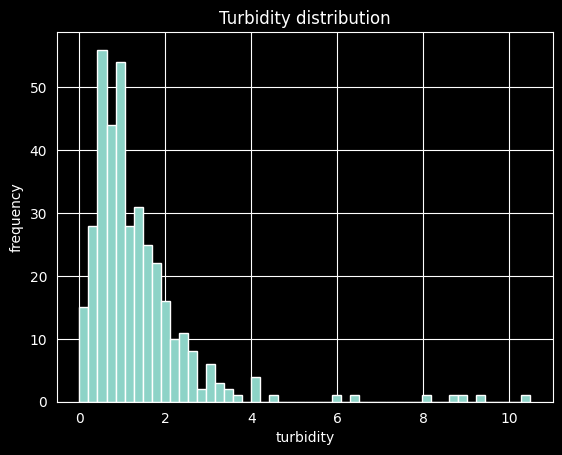

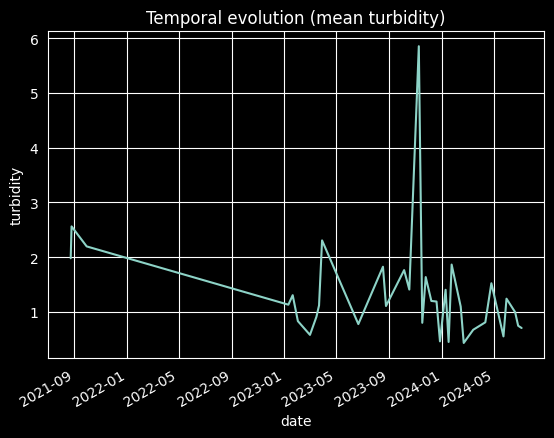


Missing ratio:
 date         0.0
turbidity    0.0
ctd          0.0
dtype: float64


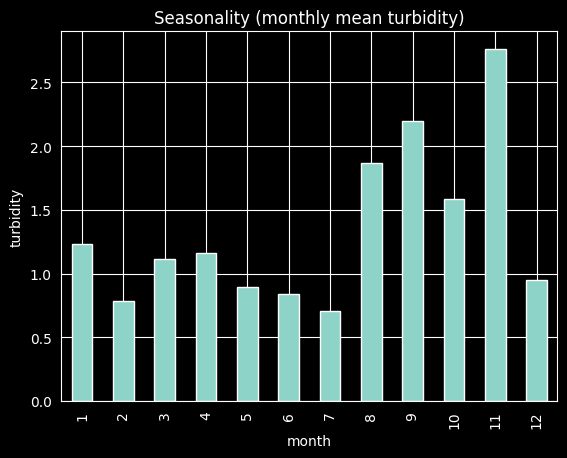

In [36]:
base_dir = Path("../data")
file_path = base_dir / "datasets" / "turbidity_ctd_satellite.csv"

df = pd.read_csv(file_path)

df = df.rename(columns={
    "station": "ctd",
    "Date": "date",
    "turbidity_surface": "turbidity"
})

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
df = df.sort_values(["ctd", "date"])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())

target_col = "turbidity"
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

summary = df.groupby("ctd")[target_col].agg(["count", "mean", "std", "min", "max"])
print("\nPer-ctd statistics:\n", summary)

plt.figure()
df[target_col].hist(bins=50)
plt.title("Turbidity distribution")
plt.xlabel("turbidity")
plt.ylabel("frequency")
plt.show()

plt.figure()
df.groupby("date")[target_col].mean().plot()
plt.title("Temporal evolution (mean turbidity)")
plt.xlabel("date")
plt.ylabel("turbidity")
plt.show()

missing_ratio = df.isna().mean().sort_values(ascending=False)
print("\nMissing ratio:\n", missing_ratio)

df["month"] = df["date"].dt.month
seasonality = df.groupby("month")[target_col].mean()

plt.figure()
seasonality.plot(kind="bar")
plt.title("Seasonality (monthly mean turbidity)")
plt.xlabel("month")
plt.ylabel("turbidity")
plt.show()

df["ctd"] = df["ctd"].astype("category").cat.codes

In [37]:
df_y = pd.read_csv("../data/datasets/turbidity_ctd_satellite.csv")
df_y.head()

,date,turbidity,ctd
0,2021-08-24,1.774905,CTD10
1,2021-08-26,2.838800,CTD10
2,2021-09-30,3.155790,CTD10
3,2023-01-10,0.589949,CTD10
4,2023-01-20,1.445618,CTD10
